In [26]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import importlib

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

import source.anomalyDetector as ad
importlib.reload(ad)

import source.data_wrangling as dw
importlib.reload(dw)

<module 'source.data_wrangling' from '/home/jotje3041/thesis_2_electric_boogaloo/fystek-assignments/source/data_wrangling.py'>

## Autoencoder

#### Reading the data

In [42]:
ds_2025 = xr.open_dataset("files/2025_KVS_deployment_flagged.nc")
ds_2024 = xr.open_dataset("files/2024_KVS_deployment_flagged.nc")

In [66]:
ds_2025_1m_temp = ds_2025["temp_1m_calibrated"]
ds_2025_ir_temp = ds_2025["temp_snowsurface"]
ds_2025["temp_diff"] = ds_2025_1m_temp - ds_2025_ir_temp

ds_2024_1m_temp = ds_2024["temp_1m_calibrated"]
ds_2024_ir_temp = ds_2024["temp_snowsurface_calibrated"]
ds_2024["temp_diff"] = ds_2024_1m_temp - ds_2024_ir_temp

In [67]:
dataset_2025 = ds_2025[["temp_1m_calibrated","temp_diff"]]
labels_2025 = ds_2025["temp_1m_quality_flag"]

dataset_2024 = ds_2024[["temp_1m_calibrated","temp_diff"]]
labels_2024 = ds_2024["temp_1m_quality_flag"]

#### Scaling the data

In [83]:
def scale_dataset(dataset):
    datasets = []
    for traj in range(len(dataset.trajectory.values)):
        sel_data = dataset.isel(trajectory=traj)

        min_val = np.nanmin(sel_data["temp_1m_calibrated"])
        max_val = np.nanmax(sel_data["temp_1m_calibrated"])

        sel_data["temp_1m_calibrated"] =  (sel_data["temp_1m_calibrated"] - min_val) / (max_val - min_val)
        
        min_val = np.nanmin(sel_data["temp_diff"])
        max_val = np.nanmax(sel_data["temp_diff"])

        sel_data["temp_diff"] =  (sel_data["temp_diff"] - min_val) / (max_val - min_val)
        
        datasets.append(sel_data)    

    dataset_scaled = xr.concat(datasets,dim="trajectory")

    return dataset_scaled

In [86]:
dataset_2025_scaled = scale_dataset(dataset_2025)
#for traj in range(len(dataset_2025_scaled.trajectory)): dataset_2025_scaled["temp_1m_calibrated"].isel(trajectory=traj).plot()

In [87]:
dataset_2024_scaled = scale_dataset(dataset_2024)
#for traj in range(len(dataset_2024_scaled.trajectory)): dataset_2024_scaled["temp_1m_calibrated"].isel(trajectory=traj).plot()

#### Reshape the data

We standardize the input dataset, making sure that the measurement sample dimension is the same for both datasets (to make it easier for the autoencoder) padding with Nan values where there are no measurements. (This nan padding technique already exists in the dataset to account for variable buoy life span).

The label array is padded with zeroes, since that is coherent with the way that the padding is handled in the dataset.

The goal is to achieve a data array that is number of bouys x 2 x maximum number of measurements, so that it is like a stack of 2 x num measurements frames so that the autoencoder only has to keep track of the two constant 2 x num measurement dimensions.

In [88]:
max_measurement_len = np.max([ds_2025["time_temp"].sizes["obs_temp"],ds_2024["time_temp"].sizes["obs_temp"]])

nr_bouys_2025 = len(ds_2025.trajectory)
nr_bouys_2024 = len(ds_2024.trajectory)

array_data_2025 = np.full((nr_bouys_2025,2,max_measurement_len),np.nan)
array_labels_2025 = np.full((nr_bouys_2025,max_measurement_len),0)

array_data_2024 = np.full((nr_bouys_2024,2,max_measurement_len),np.nan)
array_labels_2024 = np.full((nr_bouys_2024,max_measurement_len),0)

print(f"2025 data shape: {array_data_2025.shape}, 2024 data shape: {array_data_2024.shape}")
print(f"2025 label shape: {array_labels_2025.shape}, 2024 label shape:{array_labels_2024.shape}")

2025 data shape: (20, 2, 3145), 2024 data shape: (33, 2, 3145)
2025 label shape: (20, 3145), 2024 label shape:(33, 3145)


In [89]:
array_data_2025 = dw.fill_data(dataset_2025,array_data_2025,["temp_1m_calibrated","temp_diff"])
array_data_2024 = dw.fill_data(dataset_2024,array_data_2024,["temp_1m_calibrated","temp_diff"])

In [90]:
array_labels_2025 = dw.fill_labels(labels_2025,array_labels_2025)
array_labels_2024 = dw.fill_labels(labels_2024,array_labels_2024)

In [91]:
train_data,test_data,train_labels,test_labels = train_test_split(array_data_2025,
                                                                 array_labels_2025,
                                                                 test_size=0.2)



In [92]:
train_data.shape,test_data.shape

((16, 2, 3145), (4, 2, 3145))

In [93]:
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[~train_labels]
normal_test_data = test_data[~test_labels]

anomalous_train_data = train_data[train_labels]
anomalous_test_data = test_data[test_labels]

IndexError: boolean index did not match indexed array along axis 1; size of axis is 2 but size of corresponding boolean axis is 3145

In [627]:
importlib.reload(ad)

autoencoder = ad.AnomalyDetector()
autoencoder.compile(optimizer='adam',loss='mae')

In [628]:
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=20,
          batch_size=512,
          validation_data=(test_data, test_data),
          shuffle=True)

Epoch 1/20


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1908 - val_loss: 0.1863
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1641 - val_loss: 0.1397
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0891 - val_loss: 0.0653
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0543 - val_loss: 0.0477
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0332 - val_loss: 0.0257
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0197 - val_loss: 0.0201
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0163 - val_loss: 0.0181
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0151 - val_loss: 0.0166
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0141 - val_loss: 0.0154
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0146 - val_loss: 0.0225
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0153 - val_loss: 0.0147
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127 - val_loss: 0.0145


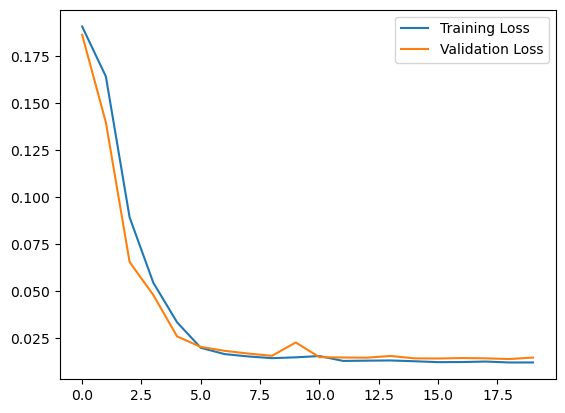

In [629]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()


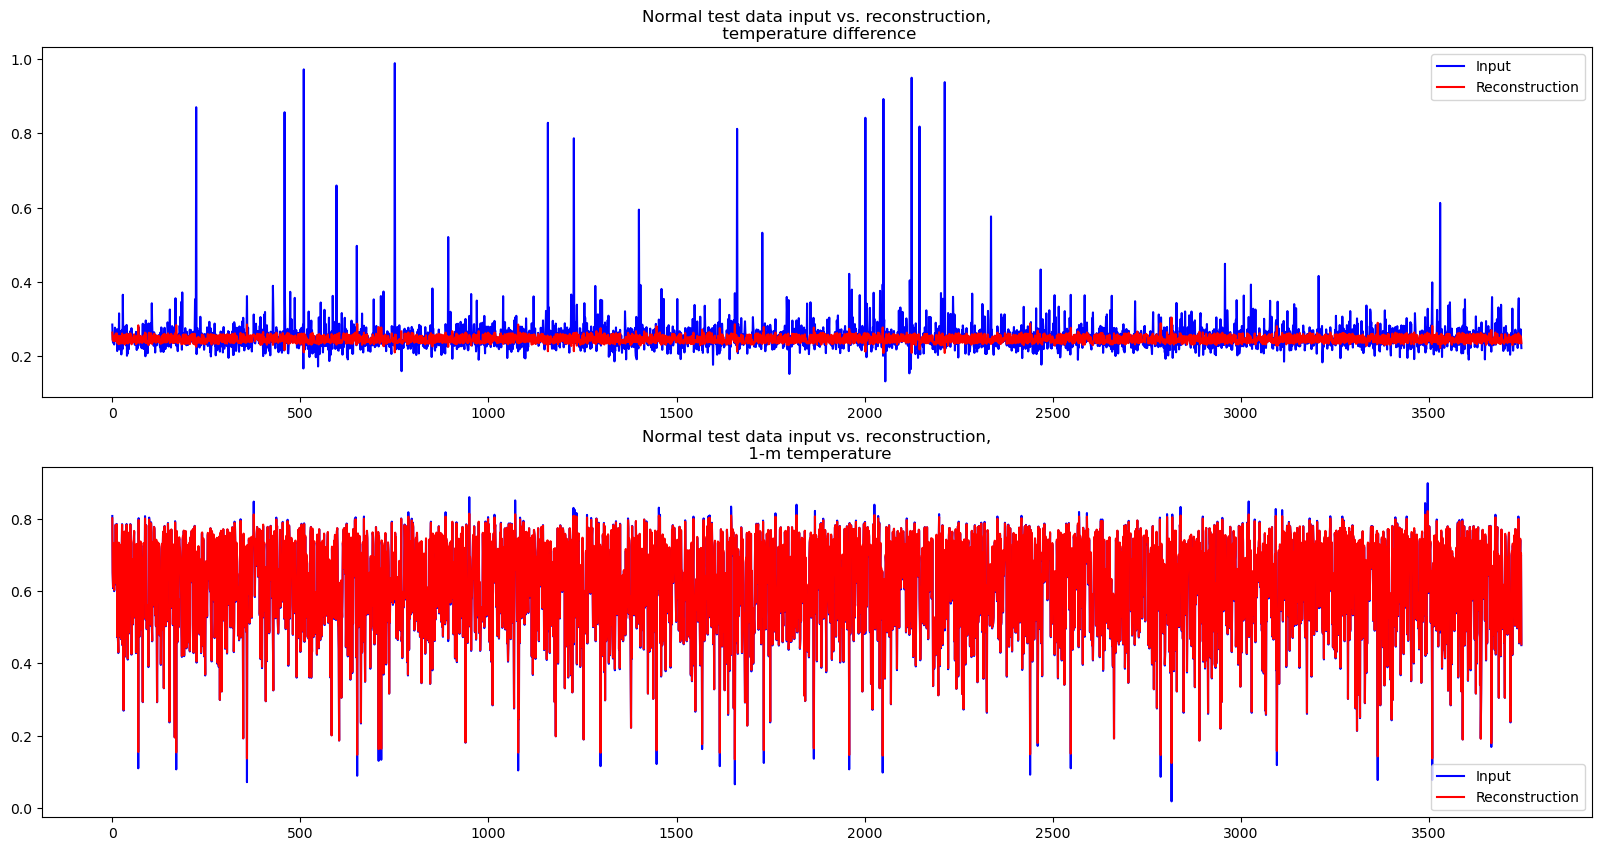

In [630]:
encoded_data = autoencoder.encoder(normal_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()

plt.figure(figsize=(20,10))

ax = plt.subplot(2,1,1)

ax.plot(normal_test_data["temp_diff"].values, 'b')
ax.plot(decoded_data[:,0], 'r')

ax.set_title("Normal test data input vs. reconstruction,\n temperature difference")
ax.legend(labels=["Input", "Reconstruction"])

ax1 = plt.subplot(2,1,2)

ax1.plot(normal_test_data["temp_1m_calibrated"].values, 'b')
ax1.plot(decoded_data[:,1], 'r')

ax1.set_title("Normal test data input vs. reconstruction,\n 1-m temperature")
ax1.legend(labels=["Input", "Reconstruction"])



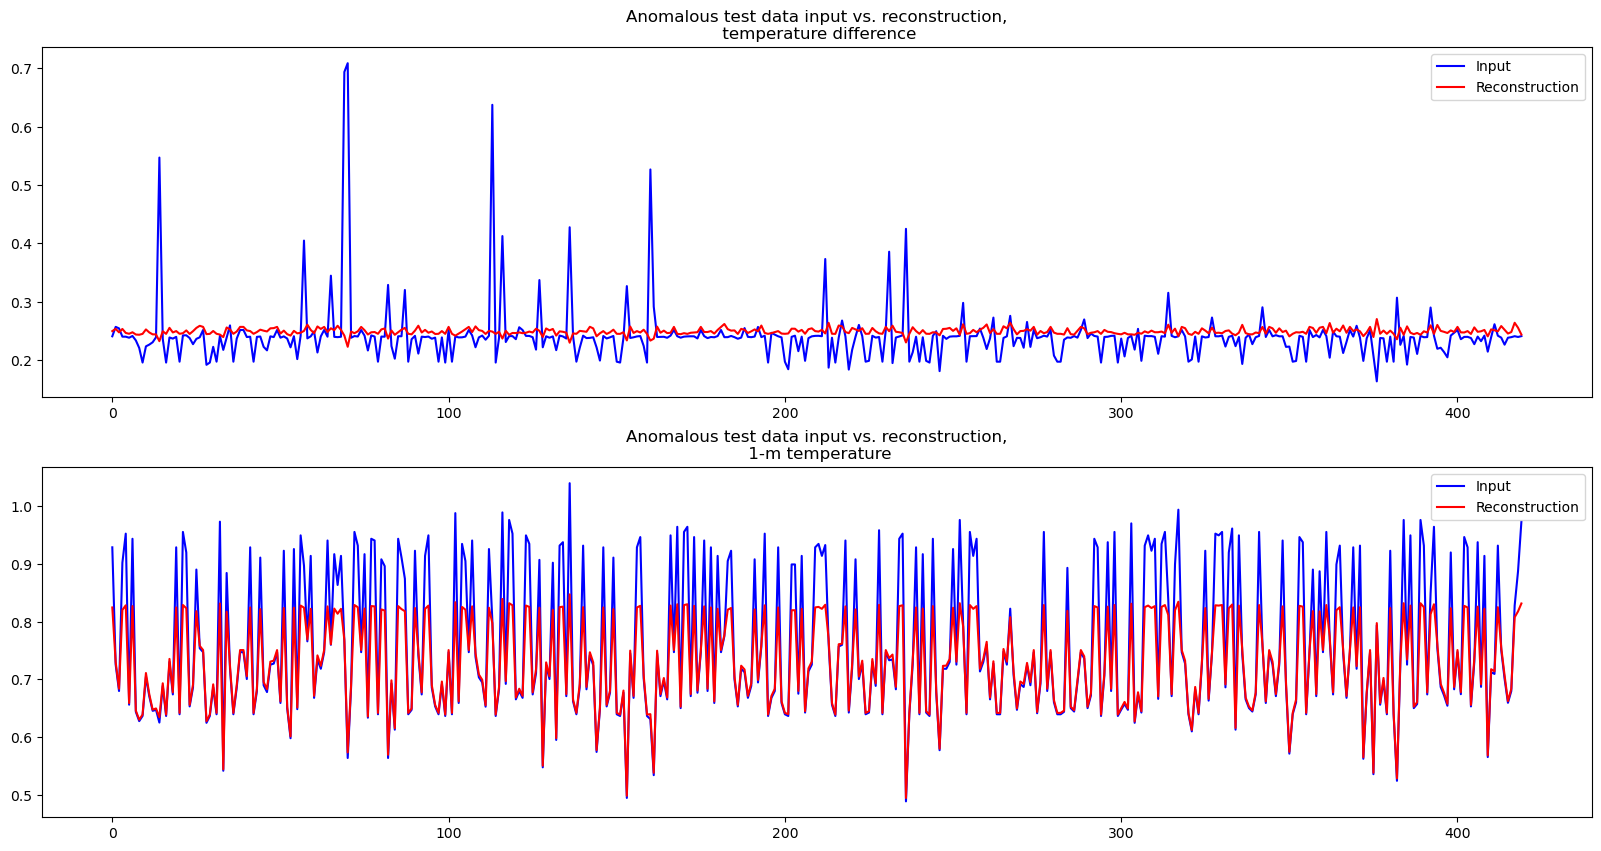

In [631]:
encoded_data = autoencoder.encoder(anomalous_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()


plt.figure(figsize=(20,10))

ax = plt.subplot(2,1,1)

ax.plot(anomalous_test_data["temp_diff"].values, 'b')
ax.plot(decoded_data[:,0], 'r')

ax.set_title("Anomalous test data input vs. reconstruction,\n temperature difference")
ax.legend(labels=["Input", "Reconstruction"])

ax1 = plt.subplot(2,1,2)

ax1.plot(anomalous_test_data["temp_1m_calibrated"].values, 'b')
ax1.plot(decoded_data[:,1], 'r')

ax1.set_title("Anomalous test data input vs. reconstruction,\n 1-m temperature")
ax1.legend(labels=["Input", "Reconstruction"])


Detect anomalies by calculating whether the reconstruction loss is greater than a fixed threshold. 

468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


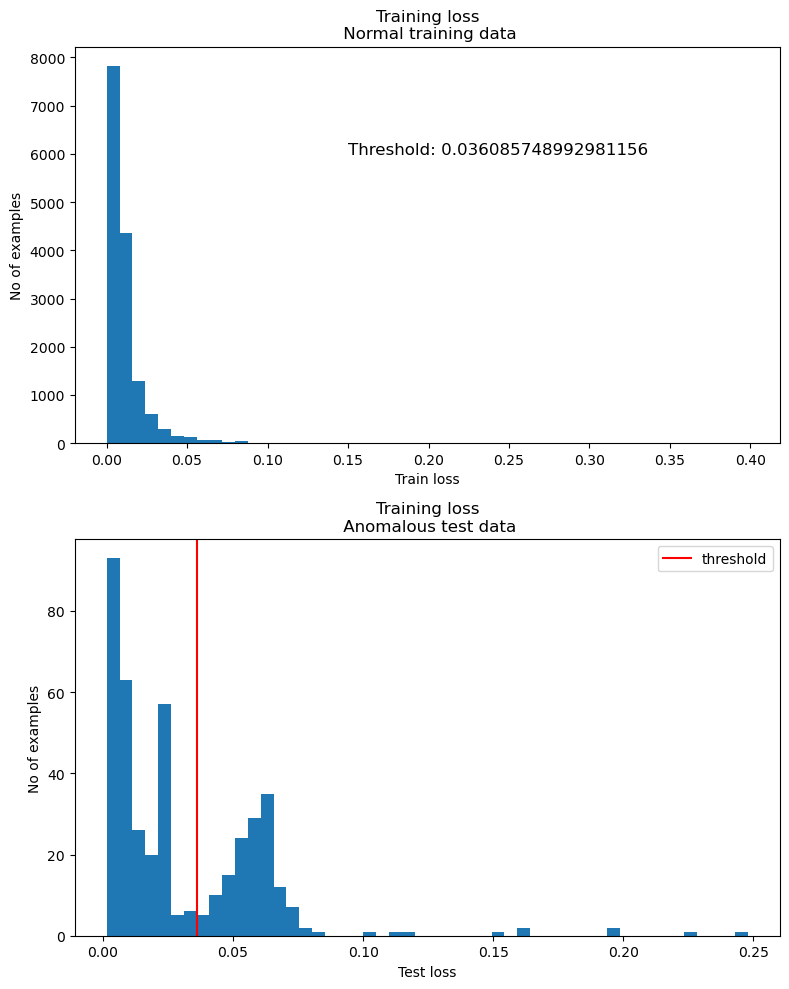

In [632]:
#=======================================================================
#Normal train
reconstructions = autoencoder.predict(normal_train_data)
train_loss = tf.keras.losses.mae(reconstructions, normal_train_data)

fig = plt.figure(figsize=(8,10))

ax = plt.subplot(2,1,1)

ax.hist(train_loss, bins=50)
ax.set_xlabel("Train loss")
ax.set_ylabel("No of examples")
ax.set_title("Training loss\n Normal training data")

threshold = np.mean(train_loss) + np.std(train_loss)
ax.text(0.15, 6000, f'Threshold: {threshold}', fontsize=12)

#=======================================================================
#Anomalous train

reconstructions = autoencoder.predict(anomalous_test_data)
test_loss = tf.keras.losses.mae(reconstructions, anomalous_test_data)

ax1 = plt.subplot(2,1,2)
ax1.hist(test_loss, bins=50)
ax1.set_xlabel("Test loss")
ax1.set_ylabel("No of examples")
ax1.set_title("Training loss\n Anomalous test data")
ax1.axvline(x=threshold,color='r',label="threshold")
ax1.legend()

plt.tight_layout()


#### Flagging test data

In [ ]:
##TO DO: PLOT AN ACTUAL BOUY WITH ANOMALY DETECTION for 2025

In [634]:
preds = AD.anomalyPredict(autoencoder, test_data, threshold)
AD.print_stats(preds, test_labels)

Accuracy = 0.11087113030957524
Precision = 0.07058823529411765
Recall = 0.6428571428571429


### Using the 2025 dataset to flag the 2024 dataset

In [650]:
flagging_data = data_2024

Text(0.5, 1.0, 'Data to flag,\n 2024')

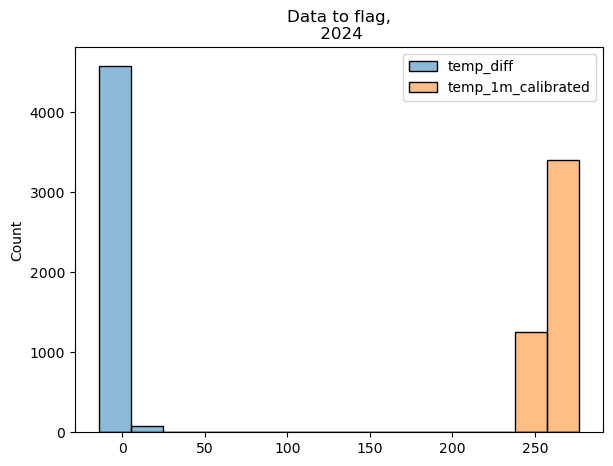

In [651]:
fig = plt.figure(figsize=(15,5))

ax = plt.subplot(1,2,1)
sns.histplot(flagging_data,ax=ax)
ax.set_title("Data to flag,\n 2024")

In [652]:
min_val = np.min(flagging_data["temp_diff"])
max_val = np.max(flagging_data["temp_diff"])

flagging_data["temp_diff"] = (flagging_data["temp_diff"] - min_val) / (max_val - min_val)

min_val = np.min(flagging_data["temp_1m_calibrated"])
max_val = np.max(flagging_data["temp_1m_calibrated"])

flagging_data["temp_1m_calibrated"] = (flagging_data["temp_1m_calibrated"] - min_val) / (max_val - min_val)


/tmp/ipykernel_229751/3435832176.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flagging_data["temp_diff"] = (flagging_data["temp_diff"] - min_val) / (max_val - min_val)
/tmp/ipykernel_229751/3435832176.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flagging_data["temp_1m_calibrated"] = (flagging_data["temp_1m_calibrated"] - min_val) / (max_val - min_val)


Text(0.5, 1.0, 'Data to flag scaled,\n 2024')

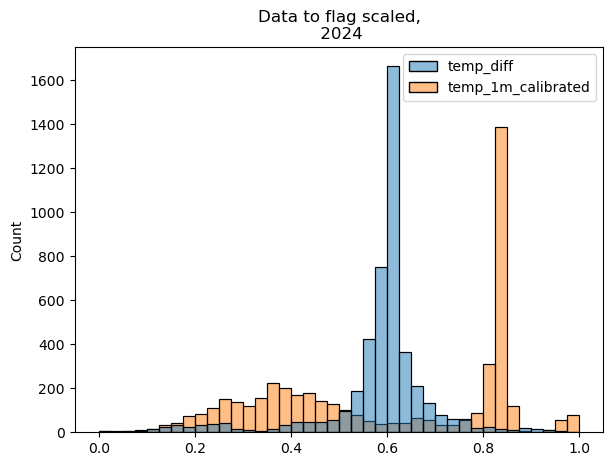

In [653]:
fig = plt.figure(figsize=(15,5))

ax = plt.subplot(1,2,1)
sns.histplot(flagging_data,ax=ax)
ax.set_title("Data to flag scaled,\n 2024")

ok so it can handle one variable dimension, because the train and test datasets are not the same size??? but in this case it is an issue????

In [654]:
preds = AD.anomalyPredict(autoencoder, flagging_data, threshold)
AD.print_stats(preds, test_labels)

ValueError: Found input variables with inconsistent numbers of samples: [4167, 4659]